In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [2]:
data = pd.read_csv("xy_data.csv")
if data.shape[1] == 2:
    data.columns = ["x", "y"]
x_obs = data["x"].values
y_obs = data["y"].values
N = len(x_obs)

In [3]:
t0 = np.linspace(6, 60, N)
p0 = np.concatenate(([25, 0.0, 50], t0))
lower = np.concatenate(([0, -0.05, 0], np.full(N, 6)))
upper = np.concatenate(([50, 0.05, 100], np.full(N, 60)))

In [4]:
def residual(p):
    theta_deg = p[0]
    M = p[1]
    X = p[2]
    t = p[3:]
    theta = np.deg2rad(theta_deg)
    exp_term = np.exp(M * np.abs(t))
    sin_term = np.sin(0.3 * t)
    x_model = (t*np.cos(theta)-exp_term*sin_term*np.sin(theta)+X)
    y_model = (42+t*np.sin(theta)+exp_term*sin_term*np.cos(theta))
    return np.concatenate([x_model - x_obs,y_model - y_obs])

In [5]:
result = least_squares(residual,p0,bounds=(lower, upper),verbose=2,ftol=1e-12,xtol=1e-12,gtol=1e-12,max_nfev=5000)
theta = result.x[0]
M = result.x[1]
X = result.x[2]
t = result.x[3:]
print("\nEstimated Parameters")
print("--------------------")
print(f"Theta = {theta:.6f} degrees")
print(f"M     = {M:.8f}")
print(f"X     = {X:.6f}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.0106e+05                                    2.84e+05    
       1              2         7.9503e+04      3.22e+05       4.99e+02       2.88e+04    
       2              3         1.6488e+04      6.30e+04       2.34e+02       7.61e+02    
       3              4         3.8159e+03      1.27e+04       1.10e+02       2.89e+03    
       4              5         3.6474e+02      3.45e+03       4.25e+01       4.17e+03    
       5              6         3.9584e+01      3.25e+02       1.65e+01       1.50e+02    
       6              7         5.7168e+00      3.39e+01       5.53e+00       1.17e+02    
       7              8         7.1749e-01      5.00e+00       2.11e+00       2.25e+01    
       8              9         8.5346e-02      6.32e-01       7.12e-01       2.64e+00    
       9             10         1.0342e-02      7.50e-02       2.39e-01       2.69e-01    

In [6]:
theta_rad = np.deg2rad(theta)
exp_term = np.exp(M*np.abs(t))
sin_term = np.sin(0.3*t)
x_fit = (t*np.cos(theta_rad)-exp_term*sin_term*np.sin(theta_rad)+X)
y_fit = (42+t*np.sin(theta_rad)+exp_term*sin_term*np.cos(theta_rad))
rmse = np.sqrt(np.mean((x_fit-x_obs)**2+(y_fit-y_obs)**2))
print("\nRMSE =", rmse)


RMSE = 2.700134271297147e-06


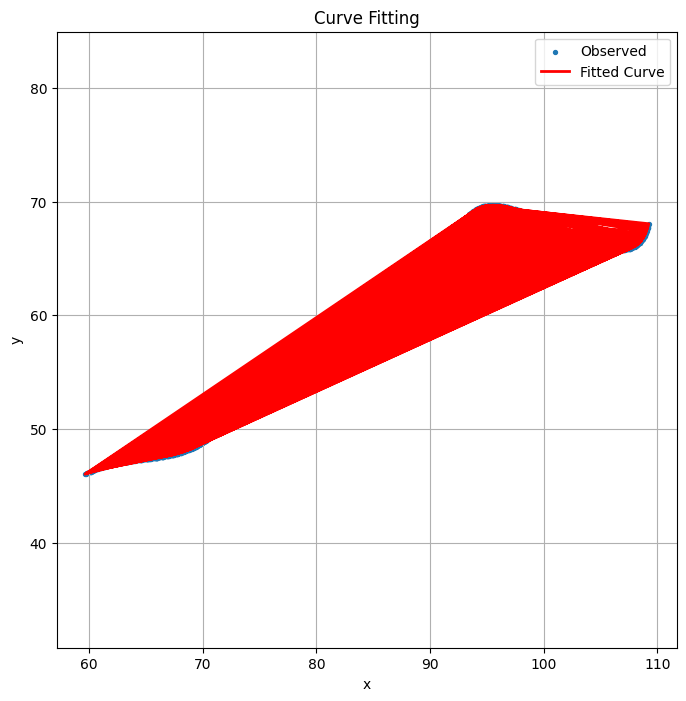

In [7]:
plt.figure(figsize=(8,8))
plt.scatter(x_obs,y_obs,s=8,label="Observed")
plt.plot(x_fit,y_fit,'r',linewidth=2,label="Fitted Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curve Fitting")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()